# 02 Modeling: Volatility Forecasting

This notebook trains and evaluates several volatility forecasting models. The notebook uses reusable helper functions from `src/` when available, while keeping the modeling workflow readable and reproducible.

Main workflow:

1. Load the processed modeling dataset from `data/model_data.csv`
2. Split the data using a time-ordered train/test split
3. Train baseline, tree-based, boosting, stacking, and GARCH models
4. Compare models using RMSE and MAE

## 1. Import packages and project utilities

The notebook uses reusable helper functions from `src/` to keep the workflow modular and reproducible.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

from xgboost import XGBRegressor
from arch import arch_model

In [2]:
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.models import get_ridge, get_rf, get_extra, get_xgb
from src.evaluation import evaluate

## 2. Load processed modeling data

The modeling dataset contains lagged realized-volatility features and next-day volatility targets.

In [3]:
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

model_data_path = DATA_DIR / "model_data.csv"
returns_path = DATA_DIR / "returns.csv"

df = pd.read_csv(model_data_path, index_col=0, parse_dates=True)
returns = pd.read_csv(returns_path, index_col=0, parse_dates=True)

df.head()

,vol,vol_lag1,vol_lag5,vol_lag10,vol_lag21,target
Date,,,,,,
2015-03-05,0.076596,0.088954,0.117697,0.138447,0.178846,0.092105
2015-03-06,0.092105,0.076596,0.106632,0.138762,0.167061,0.086748
2015-03-09,0.086748,0.092105,0.104768,0.130694,0.165993,0.104233
2015-03-10,0.104233,0.086748,0.092912,0.128510,0.161693,0.103366
2015-03-11,0.103366,0.104233,0.088954,0.128742,0.150427,0.106206


In [4]:
feature_cols = ["vol_lag1", "vol_lag5", "vol_lag10", "vol_lag21"]

X = df[feature_cols]
y = df["target"]

## 3. Time-ordered train/test split

Because this is a time-series forecasting problem, we do not randomly shuffle the data. The first 80% of observations are used for training, and the remaining 20% are held out for testing.

In [5]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

## 4. Baseline model

The baseline predicts tomorrow's volatility using today's volatility. This is a strong benchmark because volatility is highly persistent.

In [6]:
y_pred_baseline = X_test["vol_lag1"]

baseline_rmse, baseline_mae = evaluate(y_test, y_pred_baseline)

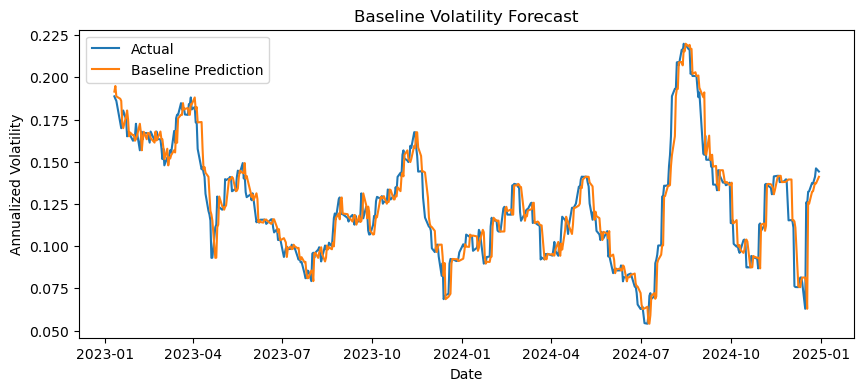

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_baseline, label="Baseline Prediction")
plt.title("Baseline Volatility Forecast")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.show()

## 5. Machine learning models

This section trains and evaluates multiple forecasting models, including linear, tree-based, boosting, and ensemble methods.

In [8]:
models = {
    "Ridge": get_ridge(),
    "Random Forest": get_rf(),
    "Extra Trees": get_extra(),
    "XGBoost": get_xgb()
}

predictions = {}
metrics = {
    "Baseline": {
        "RMSE": baseline_rmse,
        "MAE": baseline_mae
    }
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse, mae = evaluate(y_test, y_pred)

    predictions[name] = pd.Series(y_pred, index=y_test.index)
    metrics[name] = {"RMSE": rmse, "MAE": mae}

## 6. Stacking model

The stacking model combines linear, bagging, and boosting-based learners using Ridge regression as the meta-model. This allows the final model to combine linear, bagging, and boosting-based predictions.

In [9]:
base_models = [
    ("ridge", get_ridge()),
    ("rf", get_rf()),
    ("extra", get_extra()),
    ("xgb", XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
]

stacking = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge(alpha=1.0),
    passthrough=True,
    cv=5
)

stacking.fit(X_train, y_train)

y_pred_stack = stacking.predict(X_test)
stack_rmse, stack_mae = evaluate(y_test, y_pred_stack)

predictions["Stacking"] = pd.Series(y_pred_stack, index=y_test.index)
metrics["Stacking"] = {"RMSE": stack_rmse, "MAE": stack_mae}

## 7. Hyperparameter tuning with time-series cross-validation

RandomizedSearchCV combined with TimeSeriesSplit was used to reduce look-ahead bias while tuning XGBoost hyperparameters.

In [10]:
ts_cv = TimeSeriesSplit(n_splits=5)

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.03, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=15,
    cv=ts_cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_xgb_model = search.best_estimator_
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

xgb_tuned_rmse, xgb_tuned_mae = evaluate(y_test, y_pred_xgb_tuned)

predictions["Tuned XGBoost"] = pd.Series(y_pred_xgb_tuned, index=y_test.index)
metrics["Tuned XGBoost"] = {"RMSE": xgb_tuned_rmse, "MAE": xgb_tuned_mae}

print("Best XGBoost parameters:")
print(search.best_params_)

Best XGBoost parameters:
{'subsample': 1.0, 'n_estimators': 500, 'max_depth': 2, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


## 8. GARCH(1,1) benchmark

GARCH(1,1) is included as a classical econometric benchmark for volatility forecasting. Returns are multiplied by 100 before fitting for numerical stability, and the forecasted volatility is converted back to annualized decimal units for comparison with the machine learning models.

In [11]:
spy_returns = returns["SPY"] * 100

spy_train = spy_returns.loc[X_train.index]
spy_test = spy_returns.loc[X_test.index]

garch = arch_model(
    spy_train,
    vol="Garch",
    p=1,
    q=1,
    mean="Constant",
    dist="normal"
)

garch_result = garch.fit(disp="off")
print(f"Omega: {garch_result.params['omega']:.4f}")
print(f"Alpha: {garch_result.params['alpha[1]']:.4f}")
print(f"Beta:  {garch_result.params['beta[1]']:.4f}")

Omega: 0.0380
Alpha: 0.2185
Beta:  0.7635


In [12]:
forecast = garch_result.forecast(horizon=len(spy_test), reindex=False)

garch_var = forecast.variance.values[-1, :]
garch_vol = np.sqrt(garch_var) * np.sqrt(252) / 100

garch_pred = pd.Series(garch_vol, index=y_test.index)

garch_rmse, garch_mae = evaluate(y_test, garch_pred)

predictions["GARCH(1,1)"] = garch_pred
metrics["GARCH(1,1)"] = {"RMSE": garch_rmse, "MAE": garch_mae}

## 9. Model comparison

RMSE and MAE are used to compare forecast accuracy. Lower values indicate better predictive performance.

In [13]:
results = (
    pd.DataFrame(metrics)
    .T
    .reset_index()
    .rename(columns={"index": "Model"})
    .sort_values("RMSE")
)

results

,Model,RMSE,MAE
4,XGBoost,0.009909,0.007074
6,Tuned XGBoost,0.010119,0.007107
2,Random Forest,0.010231,0.007196
0,Baseline,0.010238,0.006923
5,Stacking,0.010466,0.007258
3,Extra Trees,0.010538,0.007469
1,Ridge,0.010577,0.007483
7,"GARCH(1,1)",0.107775,0.100825


In [14]:
results.to_csv(DATA_DIR / "model_comparison.csv", index=False)

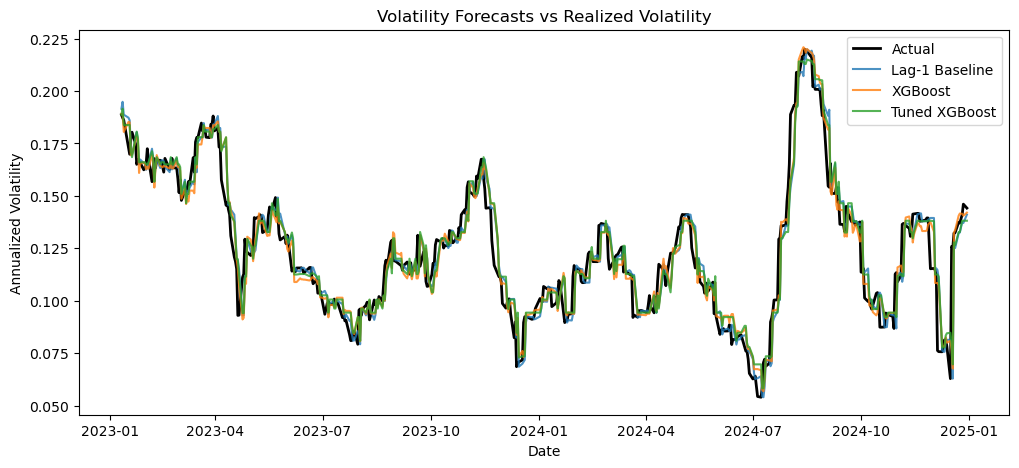

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(y_test.index, y_test, label="Actual", linewidth=2, color="black")
plt.plot(y_test.index, y_pred_baseline, label="Lag-1 Baseline", alpha=0.8)
plt.plot(predictions["XGBoost"].index, predictions["XGBoost"], label="XGBoost", alpha=0.8)
plt.plot(predictions["Tuned XGBoost"].index, predictions["Tuned XGBoost"], label="Tuned XGBoost", alpha=0.8)

plt.title("Volatility Forecasts vs Realized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.show()

XGBoost achieved the strongest out-of-sample forecasting performance, while the lag-1 baseline remained competitive due to the persistence of realized volatility.

## 10. Save predictions for VaR application

The next notebook, `03_application_var.ipynb`, can use these saved predictions to construct dynamic VaR estimates.

In [16]:
prediction_df = pd.DataFrame(index=y_test.index)
prediction_df["actual_vol"] = y_test
prediction_df["baseline"] = y_pred_baseline

for name, pred in predictions.items():
    clean_name = name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace(",", "")
    prediction_df[clean_name] = pred

prediction_df.to_csv(DATA_DIR / "model_predictions.csv")
prediction_df.head()

,actual_vol,baseline,ridge,random_forest,extra_trees,xgboost,stacking,tuned_xgboost,garch11
Date,,,,,,,,,
2023-01-11,0.188727,0.191556,0.183849,0.187939,0.190331,0.189155,0.185703,0.188618,0.179953
2023-01-12,0.187297,0.194859,0.188455,0.191195,0.192542,0.189055,0.191799,0.191560,0.180989
2023-01-13,0.186048,0.188727,0.185617,0.184646,0.189492,0.180516,0.187001,0.183754,0.182000
2023-01-17,0.173276,0.187297,0.186813,0.184498,0.188184,0.185283,0.189528,0.183806,0.182987
2023-01-18,0.169871,0.186048,0.185003,0.184435,0.187369,0.185098,0.187472,0.183806,0.183952


## 11. Interpretation

The baseline model is difficult to beat because volatility is highly persistent: recent volatility is often a strong predictor of near-future volatility. Machine learning models such as Random Forest, Extra Trees, XGBoost, and Stacking may improve performance when they capture nonlinear relationships among lagged volatility features, but their improvement must be judged against the simple baseline.

GARCH(1,1) provides a finance-standard benchmark based on conditional variance dynamics. Comparing GARCH with machine learning models helps distinguish between traditional econometric volatility modeling and data-driven forecasting approaches.

Overall, the best model is the one with the lowest out-of-sample RMSE and MAE on the time-ordered test set, and that is XGboost. These forecasts can then be used in the next stage of the project to construct dynamic Value-at-Risk estimates.